<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_11(Diabetes_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diabetes Prediction Model**
`Objective:`

Training a Machine Learning classification model to predict whether a patient has diabetes based on medical attributes.

### **Importing All the Necessary Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix, classification_report



## **1. Data Loading & Exploration**

### Loading dataset using Pandas

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Kaggle Datasets/Diabetis Risk Prediction/diabetes_risk_prediction_dataset.csv")


### Showing first few rows

In [4]:
df.head()


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


### Check dataset shape

In [5]:
df.shape

(50000, 42)

### Cheeking Datatypes

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    500

### Dropping Unncessary Columns

In [7]:
df.drop(columns = ["Patient_ID", "Diabetes_Risk_Score", "AI_Health_Recommendation", "Doctor_Consultation_Needed", "BMI_CATEGORY"], inplace= True, errors= 'ignore')

In [8]:
df

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Yes,No,Yes,Yes,No,Good,Retired,Rural,4.4,Moderate
1,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,...,Yes,No,Yes,Yes,Yes,Average,Government,Rural,2.1,High
2,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,...,Yes,No,No,Yes,No,Average,Government,Urban,2.8,High
3,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,217.7,...,Yes,Yes,No,No,No,Average,Business,Rural,1.5,High
4,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,153.5,...,No,Yes,Yes,Yes,Yes,Poor,Private,Rural,1.6,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,191.5,...,Yes,No,No,No,Yes,Average,Retired,Urban,3.5,High
49996,53.0,Male,United Kingdom,179.6,64.0,19.8,114.5,198.4,6.3,110.0,...,No,No,Yes,Yes,No,Average,Government,Urban,3.4,Moderate
49997,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,208.4,...,Yes,Yes,No,Yes,Yes,Poor,Retired,Urban,2.6,High
49998,23.0,Other,Bangladesh,168.0,73.9,26.2,131.4,139.5,9.2,84.7,...,No,No,No,Yes,Yes,Good,Private,Urban,2.7,Moderate


### Check for missing values

In [9]:
df.isnull().sum()

,0
Age,497
Gender,0
Country,0
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974
Fasting_Blood_Sugar,0


### Checking Zero filled columns that shouldn't be filled with Zeros

In [10]:
missing_numeric = df.select_dtypes(include='number').isnull().sum()
missing_numeric[missing_numeric > 0]

,0
Age,497
Height_cm,2945
Weight_kg,2962
Blood_Glucose,959
HbA1c,1974
Total_Cholesterol,1000
HDL,1000
LDL,1000
Triglycerides,1000
Exercise_Hours_Per_Week,1992


In [11]:
zero_as_missing = ["Height_cm","Weight_kg","BMI","Waist_Circumference_cm","Blood_Glucose","HbA1c","Fasting_Blood_Sugar","Insulin_Level","Blood_Pressure_Systolic",
                   "Blood_Pressure_Diastolic","Total_Cholesterol","HDL","LDL","Triglycerides", "Heart_Rate","Sleep_Hours","Daily_Water_Intake_L","Age"]



In [12]:
df[zero_as_missing].eq(0).sum()


,0
Height_cm,0
Weight_kg,0
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,0
HbA1c,0
Fasting_Blood_Sugar,0
Insulin_Level,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0


No Zero-filled column is found

### Handling Missing Values

1.Handling numerical Columns first

In [13]:
#Checking numerical columns
numerical_columns = df.select_dtypes(include="number")
list(numerical_columns)


['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Waist_Circumference_cm',
 'Blood_Glucose',
 'HbA1c',
 'Fasting_Blood_Sugar',
 'Insulin_Level',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Heart_Rate',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours',
 'Daily_Water_Intake_L']

In [14]:
#Checking Numerical Missing Columns
missing_numeric = df.select_dtypes(include='number').isnull().sum()
missing_numeric


,0
Age,497
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974
Fasting_Blood_Sugar,0
Insulin_Level,0
Blood_Pressure_Systolic,0


In [15]:
#Filling missing values with their median
numeric_missing_columns = ["Age", "Height_cm", "Weight_kg", "Blood_Glucose", "HbA1c", "Total_Cholesterol", "HDL", "LDL", "Triglycerides", "Exercise_Hours_Per_Week", "Daily_Walking_Minutes", "Sleep_Hours",]

for column in numeric_missing_columns:
    df[column] = df[column].fillna(df[column].median())


In [16]:
#Rechecking Numerical Missing Columns
missing_numeric = df.select_dtypes(include='number').isnull().sum()
print("Successfully Handled Numerical Missing Values",missing_numeric)


Successfully Handled Numerical Missing Values Age                         0
Height_cm                   0
Weight_kg                   0
BMI                         0
Waist_Circumference_cm      0
Blood_Glucose               0
HbA1c                       0
Fasting_Blood_Sugar         0
Insulin_Level               0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Total_Cholesterol           0
HDL                         0
LDL                         0
Triglycerides               0
Heart_Rate                  0
Exercise_Hours_Per_Week     0
Daily_Walking_Minutes       0
Sleep_Hours                 0
Daily_Water_Intake_L        0
dtype: int64


2.Handling Categorical Columns

In [17]:
#Checking categorical  columns
categorical_columns = df.select_dtypes(exclude="number").columns
list(categorical_columns)


['Gender',
 'Country',
 'Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS',
 'Medication_Adherence',
 'Work_Type',
 'Residence_Type',
 'Diabetes_Risk']

In [18]:
#Checking Categorical Missing Columns
missing_categories = df.select_dtypes(exclude='number').isnull().sum()
missing_categories


,0
Gender,0
Country,0
Physical_Activity_Level,500
Diet_Quality,0
Sugar_Intake_Level,0
Stress_Level,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Diabetes,0
Hypertension,0


In [25]:
#Flling the missing values with their modes
missing_categorical_columns = ['Physical_Activity_Level','Medication_Adherence']

for column in missing_categorical_columns:
  df[column] =  df[column].fillna(df[column].mode()[0])

In [24]:
#Rechecking Categorical Missing Columns
missing_categories = df.select_dtypes(exclude='number').isnull().sum()

print("Successfully Handled Categorical Missing Values",missing_categories)

Successfully Handled Categorical Missing Values Gender                     0
Country                    0
Physical_Activity_Level    0
Diet_Quality               0
Sugar_Intake_Level         0
Stress_Level               0
Smoking_Status             0
Alcohol_Consumption        0
Family_History_Diabetes    0
Hypertension               0
Heart_Disease              0
Fatty_Liver                0
PCOS                       0
Medication_Adherence       0
Work_Type                  0
Residence_Type             0
Diabetes_Risk              0
dtype: int64


### **Showing basic statistics**


In [26]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000
mean,53.87238,170.017706,87.447702,30.924056,99.960790,159.905144,8.488532,142.607294,23.476724,140.171120,90.039000,220.173262,57.370296,135.016234,229.542394,85.124260,5.016764,89.92820,6.50088,2.998842
std,21.02487,14.025535,23.763593,10.290091,23.086579,51.539079,2.267625,44.681799,12.403841,29.168623,17.575503,57.212768,18.532543,48.641767,97.247581,20.390334,2.818052,51.00243,1.98647,1.152273
min,18.00000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,90.000000,60.000000,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.00000,3.00000,1.000000
25%,36.00000,158.300000,67.700000,22.700000,80.000000,115.500000,6.600000,103.900000,12.800000,115.000000,75.000000,170.775000,41.600000,93.300000,146.400000,68.000000,2.600000,46.80000,4.80000,2.000000
50%,54.00000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,140.000000,90.000000,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.80000,6.50000,3.000000
75%,72.00000,181.800000,107.200000,37.800000,119.900000,204.200000,10.400000,181.500000,34.300000,165.000000,105.000000,269.500000,73.200000,176.900000,312.900000,103.000000,7.400000,133.40000,8.20000,4.000000
max,90.00000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,190.000000,120.000000,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.00000,10.00000,5.000000


## **Checking the Target Column**

In [28]:
df["Diabetes_Risk"].value_counts()

,count
Diabetes_Risk,
High,36593
Moderate,12937
Low,470


In [29]:
df["Diabetes_Risk"].value_counts(normalize=True) * 100

,proportion
Diabetes_Risk,
High,73.186
Moderate,25.874
Low,0.940


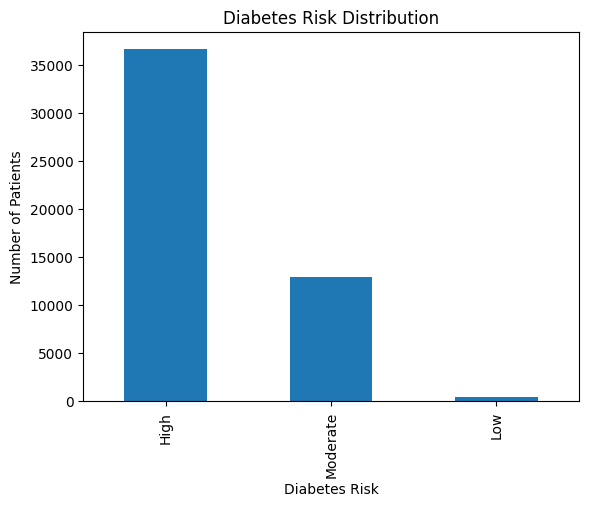

In [30]:
df["Diabetes_Risk"].value_counts().plot(kind="bar")

plt.title("Diabetes Risk Distribution")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Patients")
plt.show()

## **2 Data Preprocessing**